## PCB Pipeline



# Step 1: Frame Source

In this step, we load one input frame from an image file.

The frame source can be:
- a single image,
- an image folder,
- a video file,
- a webcam,
- an industrial camera,
- or a Raspberry Pi camera.

For this first test, we use one image as the frame source.  
The goal is only to check whether the image can be loaded correctly and to inspect its basic properties such as width, height, number of channels, and data type.

No preprocessing is applied in this step.

Frame Source Information
------------------------
Image path : /home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/IDS_Kamera_v3.bmp
Width      : 1600 px
Height     : 1200 px
Channels   : 3
Data type  : uint8


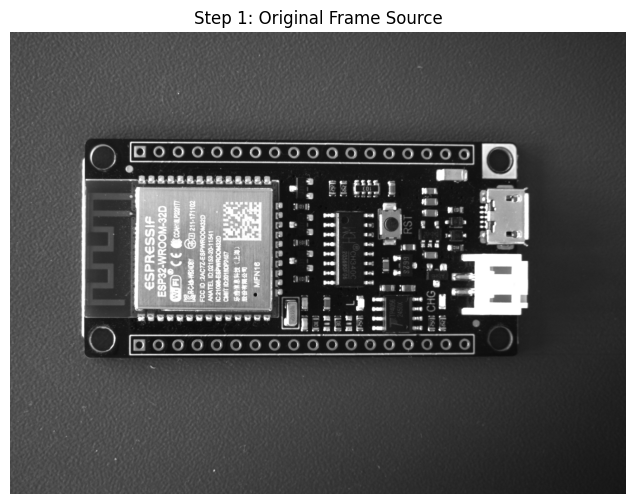

In [383]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

image_path = Path("/home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/IDS_Kamera_v3.bmp")

# Check whether the image file exists
if not image_path.exists():
    raise FileNotFoundError(f"Image file not found: {image_path}")

# Load image with OpenCV
# OpenCV loads color images in BGR format by default.
frame_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

# Check whether OpenCV could read the image
if frame_bgr is None:
    raise ValueError("The image could not be loaded. Please check the file path or file format.")

# Extract basic image information
height, width, channels = frame_bgr.shape
dtype = frame_bgr.dtype

print("Frame Source Information")
print("------------------------")
print(f"Image path : {image_path}")
print(f"Width      : {width} px")
print(f"Height     : {height} px")
print(f"Channels   : {channels}")
print(f"Data type  : {dtype}")

# Convert BGR to RGB for correct display with matplotlib
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

# Display the original frame
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("Step 1: Original Frame Source")
plt.axis("off")
plt.show()

# Step 2: Resize

In this step, we resize the input frame to a fixed processing width.

Resize is important because large camera images contain many pixels.  
More pixels mean more computation for later steps such as grayscale conversion, filtering, edge detection, contour detection, and template matching.

The goal is to reduce the image size while keeping enough detail for PCB and component detection.

In this project, common processing widths are:

- 960 px: more detail, but slower
- 720 px: good compromise
- 540 px: faster, but small components may become harder to detect

For this experiment, we use a processing width of 960 px.
The aspect ratio is preserved, so the image is not distorted.

Resize Information
------------------
Original size : 1600 x 1200 px
Resized size  : 720 x 540 px
Scale factor  : 0.450


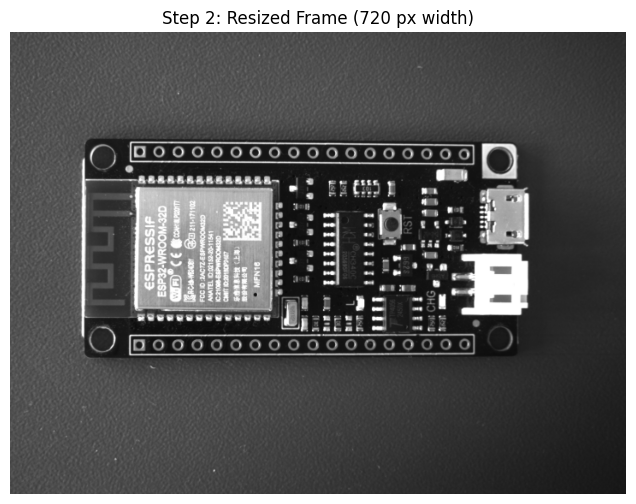

In [384]:
# ------------------------------------------------------------
# Step 2: Resize
# ------------------------------------------------------------
# In this cell, we resize the original frame to a fixed width.
# The aspect ratio is preserved.
#
# This is important because later image processing operations
# become faster when the image has fewer pixels.
# ------------------------------------------------------------

# Target processing width
proc_resize_width = 720 # before 960 px 

# Original image size
original_height, original_width = frame_bgr.shape[:2]

# Compute scale factor
scale = proc_resize_width / original_width

# Compute new height while preserving aspect ratio
new_width = proc_resize_width
new_height = int(original_height * scale)

# Resize image
frame_resized_bgr = cv2.resize(
    frame_bgr,
    (new_width, new_height),
    interpolation=cv2.INTER_AREA
)

# Print size information
print("Resize Information")
print("------------------")
print(f"Original size : {original_width} x {original_height} px")
print(f"Resized size  : {new_width} x {new_height} px")
print(f"Scale factor  : {scale:.3f}")

# Convert BGR to RGB for matplotlib display
frame_resized_rgb = cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2RGB)

# Display resized image
plt.figure(figsize=(10, 6))
plt.imshow(frame_resized_rgb)
plt.title(f"Step 2: Resized Frame ({new_width} px width)")
plt.axis("off")
plt.show()

In [385]:
print("Original frame shape:")
print(frame_bgr.shape)

print("\nResized frame shape: ")
print(frame_resized_bgr.shape)

original_pixels = frame_bgr.shape[0]*frame_bgr.shape[1]
resized_pixels = frame_resized_bgr.shape[0]*frame_resized_bgr.shape[1]

print("\nPixel count: ")
print(f"Original pixels: {original_pixels}")
print(f"Resized pixels : {resized_pixels}")
print(f"Reduction   : {(1 - resized_pixels / original_pixels)*100:.1f}%")


Original frame shape:
(1200, 1600, 3)

Resized frame shape: 
(540, 720, 3)

Pixel count: 
Original pixels: 1920000
Resized pixels : 388800
Reduction   : 79.8%


In [386]:
# ------------------------------------------------------------
# Benchmark: Measure runtime of each preprocessing step
# ------------------------------------------------------------
# This cell measures how long each preprocessing operation takes.
# Visualization is NOT included in the timing, because plotting is slow
# and does not belong to the actual computer vision pipeline.
# ------------------------------------------------------------
import cv2
import numpy as np
import time
import pandas as pd

def benchmark_preprocessing(frame_bgr, repeats = 100, warmup = 10):
    """
    Measure the average runtime of each preprocessing step.

    Parameters
    ----------
    frame_bgr:
        Input image in BGR format.
    repeats:
        Number of measured repetitions.
    warmup:
        Number of warmup runs before measurement.

    Returns
    -------
    results_df:
        DataFrame with average runtime per step in milliseconds.
    """
    timings = {
        "Grayscale" : [],
        "CLAHE": [],
        "Gaussian Blur": [],
        "canny": [],
        "Otsu Threshold": [],
        "Morphology Closing": [],
        "Morphology Opening": [],
        "Total Preprocessing": [],
    }

    clahe_operator = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8),
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (5,5)
    )
    total_runs = warmup + repeats

    for run_idx in range(total_runs):
        total_start = time.perf_counter()

        # 1. Grayscale
        t0 = time.perf_counter()
        gray = cv2.cvtColor(frame_bgr,cv2.COLOR_BGR2GRAY)
        t1 = time.perf_counter()

        # 2. CLAHE
        gray_clahe = clahe_operator.apply(gray)
        t2 = time.perf_counter()

        # 3. Gaussian Blur
        gray_blur = cv2.GaussianBlur(
            gray_clahe,
            ksize=(5,5),
            sigmaX=0
        )
        t3 = time.perf_counter()

        # 4. Canny
        canny_edges = cv2.Canny(
            gray_blur,
            threshold1=50,
            threshold2=150
        )
        t4 = time.perf_counter()

        # 5. Otsu Threshold
        _, threshold_otsu = cv2.threshold(
            gray_blur,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        t5 = time.perf_counter()

        # 6a. Morphological Closing
        morph_closed = cv2.morphologyEx(
            threshold_otsu,
            cv2.MORPH_CLOSE,
            kernel,
            iterations=1
        )
        t6 = time.perf_counter()

        # 6b. Morphological Opening
        morph_cleaned = cv2.morphologyEx(
            morph_closed,
            cv2.MORPH_OPEN,
            kernel,
            iterations=1
        )
        t7 = time.perf_counter()

        total_end = time.perf_counter()

        # skip warmpup runs
        if run_idx >= warmup:
            timings["Grayscale"].append((t1-t0)*1000)
            timings["CLAHE"].append((t2-t1)*1000)
            timings["Gaussian Blur"].append((t3 - t2) * 1000)
            timings["canny"].append((t4 - t3) * 1000)
            timings["Otsu Threshold"].append((t5 - t4) * 1000)
            timings["Morphology Closing"].append((t6 - t5) * 1000)
            timings["Morphology Opening"].append((t7 - t6) * 1000)
            timings["Total Preprocessing"].append((total_end - total_start) * 1000)

    rows = []

    for step_name, values in timings.items():
        values = np.array(values)

        rows.append({
            "Step": step_name,
            "Mean ms": values.mean(),
            "Std ms": values.std(),
            "Min ms": values.min(),
            "Max ms": values.max(),
        })
    results_df = pd.DataFrame(rows)
    return results_df
    
timing_df = benchmark_preprocessing(
    frame_resized_bgr,
    repeats=100,
    warmup=10
)

timing_df

    








,Step,Mean ms,Std ms,Min ms,Max ms
0,Grayscale,0.114712,0.035140,0.042883,0.230079
1,CLAHE,0.297397,0.084224,0.227134,0.977278
2,Gaussian Blur,0.068117,0.018509,0.051421,0.174530
3,canny,0.443366,0.090746,0.367619,0.890800
4,Otsu Threshold,0.286108,0.042822,0.202466,0.368477
5,Morphology Closing,0.205062,0.057844,0.140452,0.323747
6,Morphology Opening,0.180052,0.051586,0.133419,0.270658
7,Total Preprocessing,1.595047,0.250206,1.262813,2.766614


# Step 3: Preprocessing

In this step, we prepare the resized PCB image for later board and component detection.

Preprocessing is important because raw camera images often contain noise, reflections, shadows, uneven illumination, and weak edges.

We apply the following preprocessing steps:

1. Grayscale conversion  
   Converts the color image into a single-channel intensity image.

2. CLAHE  
   Improves local contrast and makes small PCB structures more visible.

3. Gaussian Blur  
   Reduces noise before edge detection.

4. Canny Edge Detection  
   Extracts strong edges such as board borders, component outlines, pins, and connectors.

5. Thresholding  
   Separates bright and dark image regions.

6. Morphology  
   Cleans the binary image by closing small gaps and removing small noise.

The goal of this cell is not final detection yet.  
The goal is to visually understand how each preprocessing step changes the image.

Thresholding Information
------------------------
Otsu threshold value: 127.00


,Step,Time ms
0,Grayscale,0.410720
1,CLAHE,0.946627
2,Gaussian Blur,0.279725
3,Canny Edge Detection,0.588253
4,Otsu Thresholding,0.349496
5,Morphological Closing,0.456670
6,Morphological Opening,0.593730
7,Total Preprocessing,3.625221



Runtime Summary
---------------
Total preprocessing time:3.625ms 
Preprocessing-only FPS: 275.8


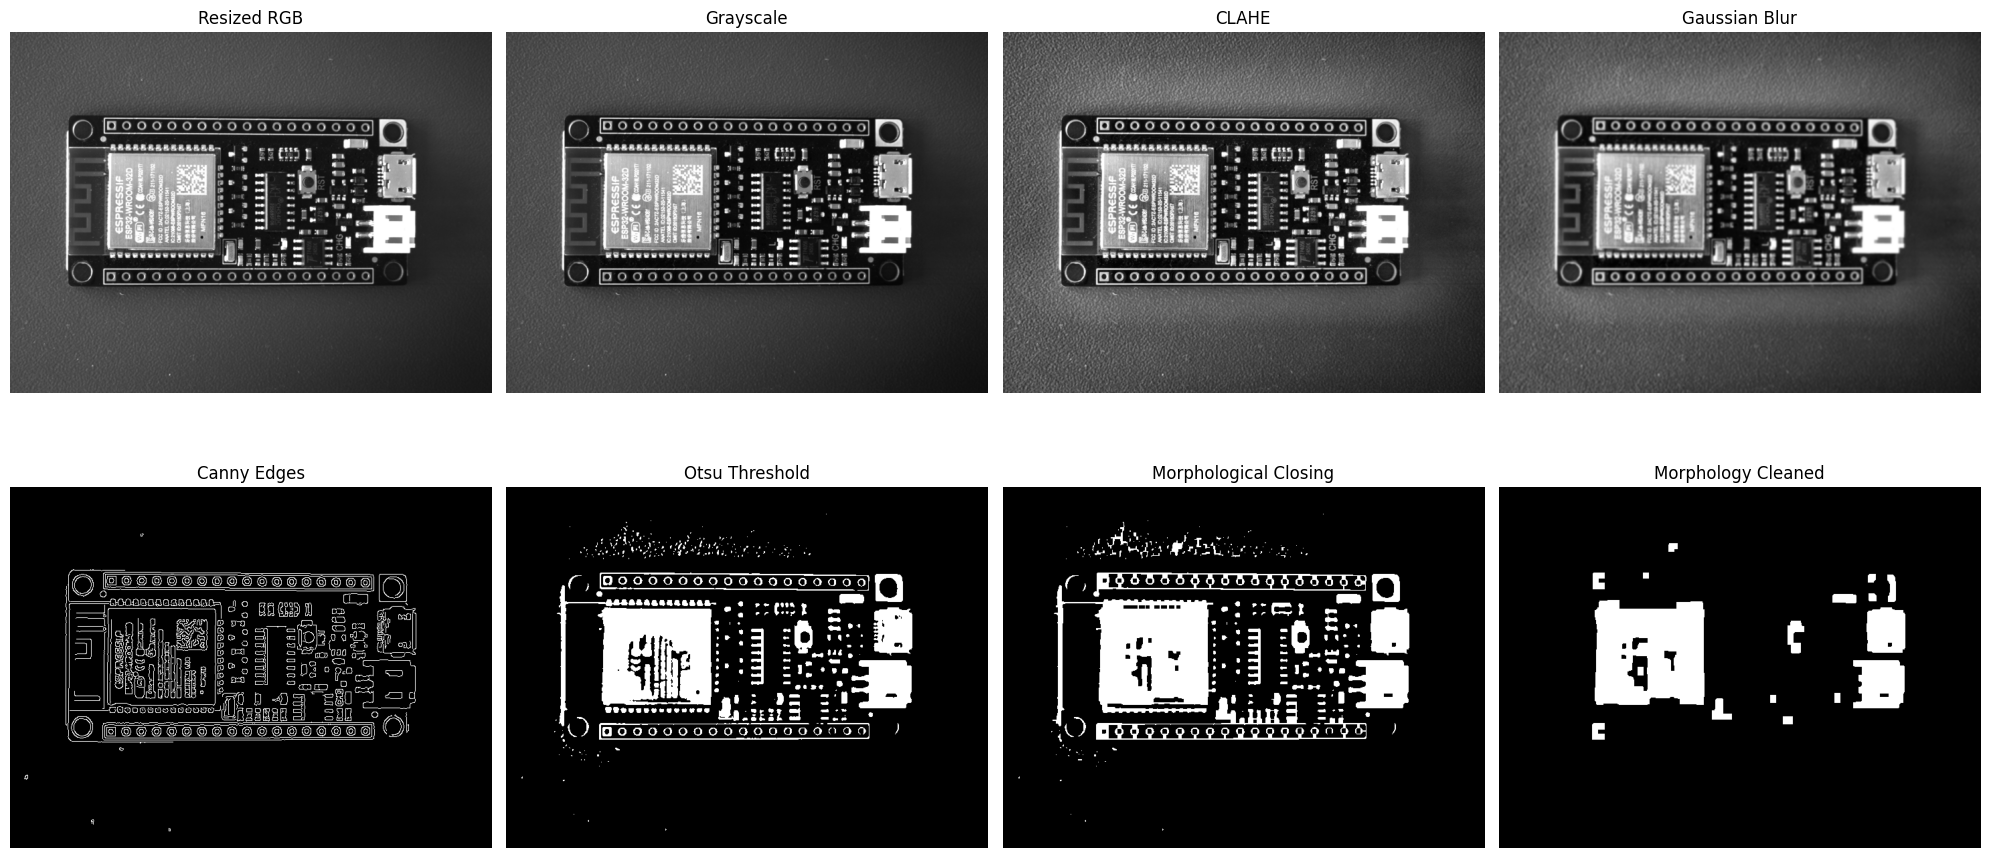

In [387]:
# ------------------------------------------------------------
# Step 3: Preprocessing
# ------------------------------------------------------------
# In this cell, we apply the main preprocessing steps used in
# a classical computer vision pipeline:
#
# 1. Grayscale
# 2. CLAHE
# 3. Gaussian Blur
# 4. Canny Edge Detection
# 5. Thresholding
# 6. Morphology
#
# The results are displayed together using subplots.
# ------------------------------------------------------------

import cv2
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd

timings = {}


# ------------------------------------------------------------
# 1. Grayscale conversion
# ------------------------------------------------------------
# Convert the resized BGR image into a grayscale image.
# Many classical image processing methods work on grayscale images
# because edges, shapes, and intensity differences are often more
# important than color.
t0 = time.perf_counter()
gray = cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2GRAY)

t1 = time.perf_counter()
timings["Grayscale"] = (t1-t0)*1000


# ------------------------------------------------------------
# 2. CLAHE
# ------------------------------------------------------------
# CLAHE means Contrast Limited Adaptive Histogram Equalization.
# It improves local contrast without over-amplifying noise too much.
# This can make PCB structures, pins, tracks, and component edges
# more visible.

t0 = time.perf_counter()
clahe_operator = cv2.createCLAHE(
    clipLimit=2.0, 
    tileGridSize=(8, 8)
) # before clip limit is : 2

gray_clahe = clahe_operator.apply(gray)

t1 = time.perf_counter()
timings["CLAHE"] = (t1 -t0)*1000



# ------------------------------------------------------------
# 3. Gaussian Blur
# ------------------------------------------------------------
# Gaussian Blur reduces small noise before edge detection.
# Canny is sensitive to noise, so a small blur helps to create
# cleaner edges.
t0 = time.perf_counter()
gray_blur = cv2.GaussianBlur(
    gray_clahe,
    ksize=(5, 5),
    sigmaX=0
) # ksize ist ungerade zahl
t1 = time.perf_counter()
timings["Gaussian Blur"] = (t1 - t0) * 1000

# ------------------------------------------------------------
# 4. Canny Edge Detection
# ------------------------------------------------------------
# Canny extracts edges based on intensity gradients.
# Important PCB structures such as the board border, USB connector,
# JST connector, ESP32 module edges, and pins should become visible.
t0 = time.perf_counter()
canny_edges = cv2.Canny(
    gray_blur,
    threshold1=100, # Lower threshold
    threshold2=200# upper threshold
) 
t1 = time.perf_counter()
timings["Canny Edge Detection"] = (t1 - t0) * 1000

# ------------------------------------------------------------
# 5. Thresholding
# ------------------------------------------------------------
# Otsu thresholding automatically chooses a threshold value.
# It separates the image into dark and bright regions.
# This can be useful for detecting the board or large dark regions.
t0 = time.perf_counter()
otsu_threshold_value, threshold_otsu = cv2.threshold(
    gray_blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
t1 = time.perf_counter()
timings["Otsu Thresholding"] = (t1 - t0) * 1000
print("Thresholding Information")
print("------------------------")
print(f"Otsu threshold value: {otsu_threshold_value:.2f}")


# ------------------------------------------------------------
# 6. Morphology
# ------------------------------------------------------------
# Morphological operations clean binary images.
# Closing fills small gaps.
# Opening removes small noise.
#
# Here we first apply closing to connect broken regions.
# Then we apply opening to remove small isolated noise.
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (5, 5)
)

t0 = time.perf_counter()
morph_closed = cv2.morphologyEx(
    threshold_otsu,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)
t1 = time.perf_counter()
timings["Morphological Closing"] = (t1 - t0) * 1000

t0 = time.perf_counter()
morph_cleaned = cv2.morphologyEx(
    morph_closed,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

t1 = time.perf_counter()
timings["Morphological Opening"] = (t1 - t0) * 1000


# ------------------------------------------------------------
# Total preprocessing time
# ------------------------------------------------------------

total_preprocessing_time = sum(timings.values())
timings["Total Preprocessing"] = total_preprocessing_time

# ------------------------------------------------------------
# Show timing table
# ------------------------------------------------------------

timing_df = pd.DataFrame([
    {
        "Step": step,
        "Time ms": value
    }
    for step, value in timings.items()
])

display(timing_df)

print("\nRuntime Summary")
print("---------------")
print(f"Total preprocessing time:{total_preprocessing_time:.3f}ms ")
print(f"Preprocessing-only FPS: {1000 / total_preprocessing_time:.1f}")


# ------------------------------------------------------------
# Visualization with subplots
# ------------------------------------------------------------
# We display all preprocessing results side by side.
# This helps us understand how every step changes the image.
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Original resized image must be converted from BGR to RGB for matplotlib
frame_resized_rgb = cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2RGB)

images = [
    (frame_resized_rgb, "Resized RGB", None),
    (gray, "Grayscale", "gray"),
    (gray_clahe, "CLAHE", "gray"),
    (gray_blur, "Gaussian Blur", "gray"),
    (canny_edges, "Canny Edges", "gray"),
    (threshold_otsu, "Otsu Threshold", "gray"),
    (morph_closed, "Morphological Closing", "gray"),
    (morph_cleaned, "Morphology Cleaned", "gray"),
]

for ax, (img, title, cmap) in zip(axes.ravel(), images):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

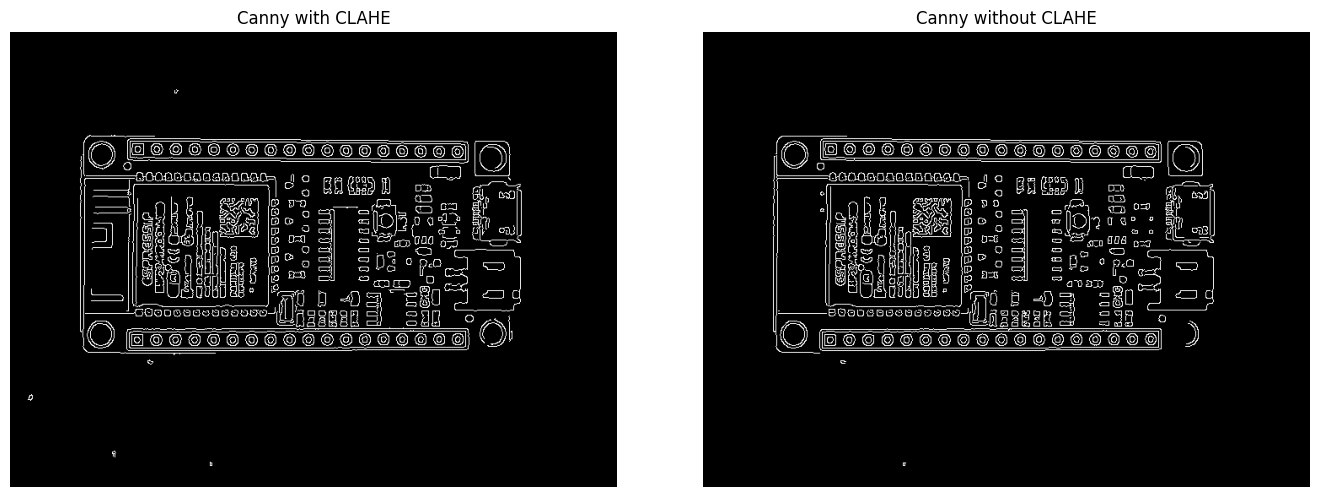

In [388]:
gray = cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2GRAY)

gray_blur_no_clahe = cv2.GaussianBlur(
    gray,
    ksize=(5, 5),
    sigmaX=0
)

canny_no_clahe = cv2.Canny(
    gray_blur_no_clahe,
    threshold1=75,
    threshold2=175
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(canny_edges, cmap="gray")
axes[0].set_title("Canny with CLAHE")
axes[0].axis("off")

axes[1].imshow(canny_no_clahe, cmap="gray")
axes[1].set_title("Canny without CLAHE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [389]:
# ------------------------------------------------------------
# Compare edge amount: Canny with CLAHE vs without CLAHE
# ------------------------------------------------------------

edge_pixels_with_clahe = np.count_nonzero(canny_edges)
edge_pixels_without_clahe = np.count_nonzero(canny_no_clahe)

total_pixels = canny_edges.shape[0] * canny_edges.shape[1]

edge_ratio_with_clahe = edge_pixels_with_clahe / total_pixels
edge_ratio_without_clahe = edge_pixels_without_clahe / total_pixels

print("Canny Edge Comparison")
print("---------------------")
print(f"With CLAHE    : {edge_pixels_with_clahe} edge pixels, ratio={edge_ratio_with_clahe:.4f}")
print(f"Without CLAHE : {edge_pixels_without_clahe} edge pixels, ratio={edge_ratio_without_clahe:.4f}")

Canny Edge Comparison
---------------------
With CLAHE    : 20273 edge pixels, ratio=0.0521
Without CLAHE : 19172 edge pixels, ratio=0.0493


# Board Candidate Detection

Canny edge image / Morphology image
        ↓
cv2.findContours()
        ↓
contours
        ↓
for each contour:
    cv2.minAreaRect(contour)
        ↓
    rect = rotated rectangle
        ↓
    rect_to_box(rect)
        ↓
    box = 4 corner points
        ↓
    analyze_rotated_rect(rect, image_shape)
        ↓
    info dictionary
        ↓
    filtering + scoring
        ↓
    candidate dictionary

# Input image types verstehen

In [390]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 1
# Inspect input data types and shapes
# ------------------------------------------------------------

print("Input variables")
print("---------------")

print(f"frame_resized_bgr type:  {type(frame_resized_bgr)}")
print(f"frame_resized_bgr shape: {frame_resized_bgr.shape}") # 3 kanal
print(f"frame_resized_bgr dtype: {frame_resized_bgr.dtype}")

print()

print(f"canny_edges type    : {type(canny_edges)}")
print(f"canny_edges shape   : {canny_edges.shape}") # 1 kanal
print(f"canny_edges dtype   : {canny_edges.dtype}")


print()

print(f"morph_cleaned type     : {type(morph_cleaned)}")
print(f"morph_cleaned shape    : {morph_cleaned.shape}") # 1 kanal
print(f"morph_cleaned dtype    : {morph_cleaned.dtype}")


Input variables
---------------
frame_resized_bgr type:  <class 'numpy.ndarray'>
frame_resized_bgr shape: (540, 720, 3)
frame_resized_bgr dtype: uint8

canny_edges type    : <class 'numpy.ndarray'>
canny_edges shape   : (540, 720)
canny_edges dtype   : uint8

morph_cleaned type     : <class 'numpy.ndarray'>
morph_cleaned shape    : (540, 720)
morph_cleaned dtype    : uint8


In [391]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 2
# Find contours from Canny edge image
# ------------------------------------------------------------

contours, hierarchy = cv2.findContours(
    canny_edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contour information") # Kontour aslinda bir nokta dizisidir. 
print("-------------------")
print(f"Number of contours: {len(contours)}")
print(f"Type of contours :  {type(contours)}")
print(f"Type of one contour: {type(contours[0])}")
print(f"Shape of first contour: {contours[0].shape}")
print(f"Hierarchy type: {type(hierarchy)}")

# ------------------------------------------------------------
# Board Candidate Detection - Cell 3
# Inspect one contour
# ------------------------------------------------------------

first_contour = contours[0]

print("First contour")
print("-------------")
print(f"Type : {type(first_contour)}")
print(f"Shape: {first_contour.shape}")
print(f"Dtype: {first_contour.dtype}")

print("\nFirst 10 points:")
print(first_contour[:10])

# ------------------------------------------------------------
# Board Candidate Detection - Cell 4
# Compute contour area
# ------------------------------------------------------------

contour_area = cv2.contourArea(first_contour)

print("Contour area")
print("------------")
print(f"Area of first contour: {contour_area:.2f} px²")


Contour information
-------------------
Number of contours: 208
Type of contours :  <class 'tuple'>
Type of one contour: <class 'numpy.ndarray'>
Shape of first contour: (5, 1, 2)
Hierarchy type: <class 'numpy.ndarray'>
First contour
-------------
Type : <class 'numpy.ndarray'>
Shape: (5, 1, 2)
Dtype: int32

First 10 points:
[[[237 510]]

 [[237 514]]

 [[239 514]]

 [[239 511]]

 [[238 511]]]
Contour area
------------
Area of first contour: 6.50 px²


In [392]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 5
# Convert contour to rotated rectangle
# ------------------------------------------------------------

rect = cv2.minAreaRect(first_contour)
print("Rotated rectangle")
print("-----------------")
print(f"rect type: {type(rect)}") # rect = ((center_x, center_y),(rect_width, rect_height),angle)
print(f"rect     : {rect}")

(center_x, center_y), (rect_width, rect_height), angle = rect


# ------------------------------------------------------------
# Board Candidate Detection - Cell 6
# Convert rotated rectangle to 4 corner points
# ------------------------------------------------------------
def rect_to_box(rect):
    """
    Convert a cv2.minAreaRect result into integer corner points.
    """
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    return box

box = rect_to_box(rect)

print("Box points")
print("----------")
print(f"box type : {type(box)}")
print(f"box shape: {box.shape}")
print(box)



Rotated rectangle
-----------------
rect type: <class 'tuple'>
rect     : ((238.0, 512.0), (4.0, 2.0), -90.0)
Box points
----------
box type : <class 'numpy.ndarray'>
box shape: (4, 2)
[[239 514]
 [237 514]
 [237 510]
 [239 510]]


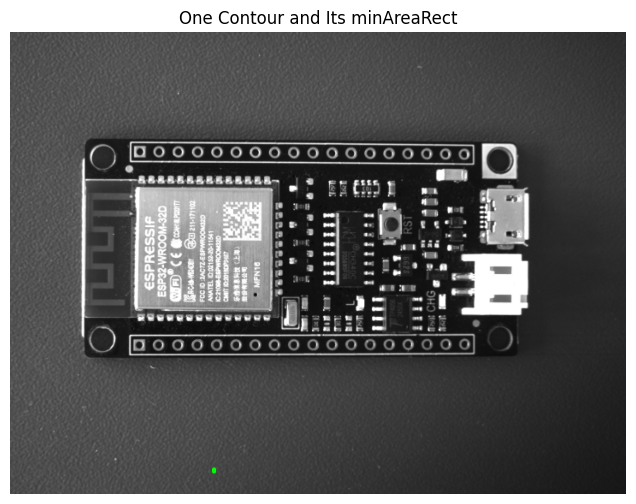

In [393]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 7
# Draw one contour and its rotated rectangle
# ------------------------------------------------------------

debug_vis = frame_resized_bgr.copy()

# Draw original contour in blue
cv2.drawContours(
    debug_vis,
    [first_contour],
    contourIdx=0,
    color=(255,0,0),
    thickness=2
)

# Draw rotated rectangle in green

cv2.drawContours(
    debug_vis,
    [box],
    contourIdx=0,
    color=(0,255,0),
    thickness=2
)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB))
plt.title("One Contour and Its minAreaRect")
plt.axis("off")
plt.show()

In [394]:
# ------------------------------------------------------------
# Select the largest contour instead of the first contour
# ------------------------------------------------------------

# Sort contours by contour area, largest first
contours_sorted = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)

largest_contour = contours_sorted[0]

print("Largest contour")
print("---------------")
print(f"Area: {cv2.contourArea(largest_contour):.2f}")
print(f"Shape: {largest_contour.shape}")

# Convert largest contour to rotated rectangle
rect = cv2.minAreaRect(largest_contour)

print("\nRotated rectangle of largest contour")
print("------------------------------------")
print(f"rect: {rect}")

(center_x, center_y), (rect_width, rect_height), angle = rect

print(f"center_x    : {center_x:.2f}")
print(f"center_y    : {center_y:.2f}")
print(f"rect_width  : {rect_width:.2f}")
print(f"rect_height : {rect_height:.2f}")
print(f"angle       : {angle:.2f}")

# Convert rect to 4 corner points
box = rect_to_box(rect)

print("\nBox points")
print("----------")
print(box)

Largest contour
---------------
Area: 23102.00
Shape: (76, 1, 2)

Rotated rectangle of largest contour
------------------------------------
rect: ((226.0, 253.5), (145.0, 162.0), -90.0)
center_x    : 226.00
center_y    : 253.50
rect_width  : 145.00
rect_height : 162.00
angle       : -90.00

Box points
----------
[[307 326]
 [145 326]
 [145 181]
 [307 181]]


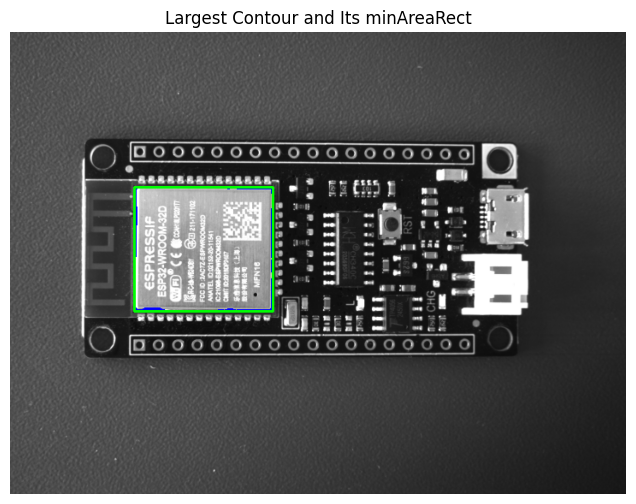

In [395]:
# ------------------------------------------------------------
# Draw largest contour and its minAreaRect
# ------------------------------------------------------------

debug_vis = frame_resized_bgr.copy()

# Draw largest contour in blue
cv2.drawContours(
    debug_vis,
    [largest_contour],
    contourIdx=0,
    color=(255, 0, 0),  # blue in BGR
    thickness=2
)

# Draw rotated rectangle in green
cv2.drawContours(
    debug_vis,
    [box],
    contourIdx=0,
    color=(0, 255, 0),  # green in BGR
    thickness=2
)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB))
plt.title("Largest Contour and Its minAreaRect")
plt.axis("off")
plt.show()

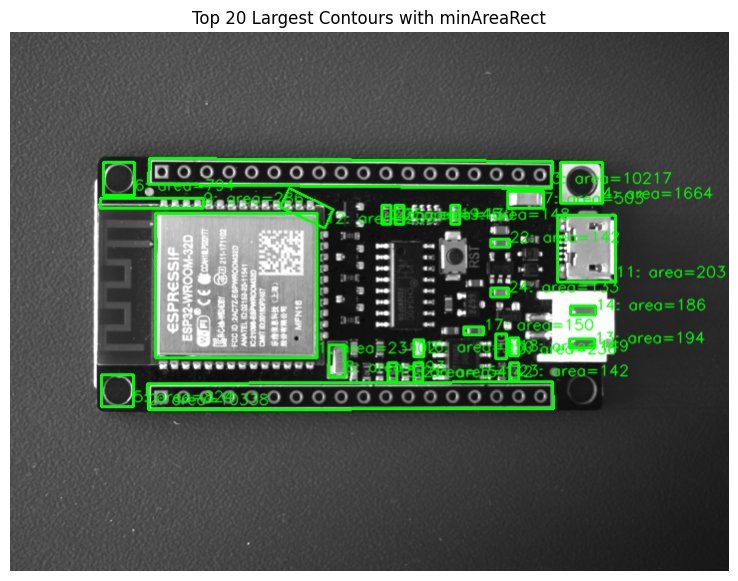

In [396]:
# ------------------------------------------------------------
# Draw top 10 largest contours and their minAreaRect boxes
# ------------------------------------------------------------

debug_vis = frame_resized_bgr.copy()

top_n = 25

for idx, contour in enumerate(contours_sorted[:top_n]):
    rect = cv2.minAreaRect(contour)
    box = rect_to_box(rect)

    area = cv2.contourArea(contour)

    # Draw rotated rectangle
    cv2.drawContours(
        debug_vis,
        [box],
        contourIdx=0,
        color=(0, 255, 0),
        thickness=2
    )

    # Write index and area
    x, y = box[0]
    label = f"{idx+1}: area={area:.0f}"

    cv2.putText(
        debug_vis,
        label,
        (int(x), int(y) - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(debug_vis, cv2.COLOR_BGR2RGB))
plt.title("Top 20 Largest Contours with minAreaRect")
plt.axis("off")
plt.show()

In [397]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 8
# Analyze rotated rectangle geometry
# ------------------------------------------------------------
# ------------------------------------------------------------
# Board Candidate Detection - Cell 8
# Analyze rotated rectangle geometry
# ------------------------------------------------------------

def analyze_rotated_rect(rect, image_shape):
    """
    Analyze a rotated rectangle and compute geometric properties.
    """
    image_height, image_width = image_shape[:2]
    image_area = image_width * image_height

    (center_x, center_y), (rect_width, rect_height), angle = rect

    if rect_width <= 0 or rect_height <= 0:
        return None

    rect_area = rect_width * rect_height
    area_ratio = rect_area / image_area

    long_side = max(rect_width, rect_height)
    short_side = min(rect_width, rect_height)

    if short_side <= 0:
        return None

    aspect_ratio = long_side / short_side

    return {
        "center": (center_x, center_y),
        "width": rect_width,
        "height": rect_height,
        "area": rect_area,
        "area_ratio": area_ratio,
        "aspect_ratio": aspect_ratio,
        "angle": angle,
    }

info = analyze_rotated_rect(rect, frame_resized_bgr.shape)

print("Geometry info")
print("-------------")
print(info)


Geometry info
-------------
{'center': (389.5, 182.5), 'width': 19.0, 'height': 9.0, 'area': 171.0, 'area_ratio': 0.0004398148148148148, 'aspect_ratio': 2.111111111111111, 'angle': -90.0}


In [398]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 9
# Manual calculation of area ratio and aspect ratio
# ------------------------------------------------------------

image_height, image_width = frame_resized_bgr.shape[:2]
image_area = image_width * image_height

(center_x, center_y), (rect_width, rect_height), angle = rect

rect_area = rect_width * rect_height
area_ratio = rect_area / image_area

long_side = max(rect_width, rect_height)
short_side = min(rect_width, rect_height)
aspect_ratio = long_side / short_side

print("Manual geometry calculation")
print("---------------------------")
print(f"Image width      : {image_width}")
print(f"Image height     : {image_height}")
print(f"Image area       : {image_area}")

print()

print(f"Rect width       : {rect_width:.2f}")
print(f"Rect height      : {rect_height:.2f}")
print(f"Rect area        : {rect_area:.2f}")

print()

print(f"Area ratio       : {area_ratio:.4f}")
print(f"Aspect ratio     : {aspect_ratio:.2f}")
print(f"Angle            : {angle:.2f}")

Manual geometry calculation
---------------------------
Image width      : 720
Image height     : 540
Image area       : 388800

Rect width       : 19.00
Rect height      : 9.00
Rect area        : 171.00

Area ratio       : 0.0004
Aspect ratio     : 2.11
Angle            : -90.00


In [399]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 10
# Inspect geometry of all contours
# ------------------------------------------------------------

rows = []

for idx, contour in enumerate(contours):
    contour_area = cv2.contourArea(contour)

    if contour_area < 100:
        continue

    rect = cv2.minAreaRect(contour)
    info = analyze_rotated_rect(rect, frame_resized_bgr.shape)

    if info is None:
        continue

    rows.append({
        "idx": idx,
        "contour_area": contour_area,
        "rect_width": info["width"],
        "rect_height": info["height"],
        "rect_area": info["area"],
        "area_ratio": info["area_ratio"],
        "aspect_ratio": info["aspect_ratio"],
        "angle": info["angle"],
    })

import pandas as pd

contour_df = pd.DataFrame(rows)
contour_df = contour_df.sort_values("rect_area", ascending=False)

contour_df.head(20)

,idx,contour_area,rect_width,rect_height,rect_area,area_ratio,aspect_ratio,angle
23,174,23102.0,145.000000,162.000000,23490.000000,0.060417,1.117241,-90.000000
0,4,10338.5,406.056671,26.869139,10910.393024,0.028062,15.112381,-0.187240
33,205,10217.0,26.611603,404.181641,10755.921273,0.027664,15.188174,-89.555855
22,171,203.0,67.000000,58.000000,3886.000000,0.009995,1.155172,-90.000000
31,203,1663.5,41.000000,42.000000,1722.000000,0.004429,1.024390,-90.000000
19,148,113.5,83.999985,17.999996,1511.999405,0.003889,4.666667,-90.000000
29,199,286.5,9.999998,102.999985,1029.999651,0.002649,10.300000,-90.000000
1,8,823.5,32.000000,32.000000,1024.000000,0.002634,1.000000,-90.000000
32,204,793.5,33.000000,31.000000,1023.000000,0.002631,1.064516,-90.000000
28,191,203.0,20.934532,48.552181,1016.417200,0.002614,2.319239,-65.136307


In [400]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 11
# Apply area ratio and aspect ratio filters
# ------------------------------------------------------------

min_area_ratio = 0.005
max_area_ratio = 0.95

min_aspect_ratio = 0.8
max_aspect_ratio = 5.0

filtered_df = contour_df[
    (contour_df["area_ratio"] >= min_area_ratio) &
    (contour_df["area_ratio"] <= max_area_ratio) &
    (contour_df["aspect_ratio"] >= min_aspect_ratio) &
    (contour_df["aspect_ratio"] <= max_aspect_ratio)
].copy()

print("Filtering result")
print("----------------")
print(f"Before filtering: {len(contour_df)}")
print(f"After filtering : {len(filtered_df)}")

filtered_df.head(20)

Filtering result
----------------
Before filtering: 34
After filtering : 2


,idx,contour_area,rect_width,rect_height,rect_area,area_ratio,aspect_ratio,angle
23,174,23102.0,145.0,162.0,23490.0,0.060417,1.117241,-90.0
22,171,203.0,67.0,58.0,3886.0,0.009995,1.155172,-90.0


In [401]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 12
# Compute geometry score
# ------------------------------------------------------------

expected_aspect = 900 / 460

filtered_df["aspect_error"] = abs(filtered_df["aspect_ratio"] - expected_aspect)

filtered_df["aspect_score"] = 1.0 - filtered_df["aspect_error"] / expected_aspect
filtered_df["aspect_score"] = filtered_df["aspect_score"].clip(lower=0.0, upper=1.0)

filtered_df["area_score"] = filtered_df["area_ratio"] / 0.25
filtered_df["area_score"] = filtered_df["area_score"].clip(lower=0.0, upper=1.0)

filtered_df["geometry_score"] = (
    0.6 * filtered_df["aspect_score"] +
    0.4 * filtered_df["area_score"]
)

filtered_df = filtered_df.sort_values("geometry_score", ascending=False)

filtered_df[
    [
        "idx",
        "area_ratio",
        "aspect_ratio",
        "aspect_error",
        "aspect_score",
        "area_score",
        "geometry_score",
        "angle",
    ]
].head(20)

,idx,area_ratio,aspect_ratio,aspect_error,aspect_score,area_score,geometry_score,angle
23,174,0.060417,1.117241,0.839280,0.571034,0.241667,0.439287,-90.0
22,171,0.009995,1.155172,0.801349,0.590421,0.039979,0.370245,-90.0


In [402]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 13
# Build one candidate dictionary manually
# ------------------------------------------------------------

best_row = filtered_df.iloc[0]
best_idx = int(best_row["idx"])

best_contour = contours[best_idx]
best_rect = cv2.minAreaRect(best_contour)
best_box = rect_to_box(best_rect)
best_info = analyze_rotated_rect(best_rect, frame_resized_bgr.shape)

best_candidate = {
    "source": "canny",
    "contour": best_contour,
    "rect": best_rect,
    "box": best_box,
    "info": best_info,
    "geometry_score": best_row["geometry_score"],
}

print("Candidate dictionary keys")
print("-------------------------")
print(best_candidate.keys())

print("\nCandidate source:")
print(best_candidate["source"])

print("\nCandidate rect:")
print(best_candidate["rect"])

print("\nCandidate box:")
print(best_candidate["box"])

print("\nCandidate info:")
print(best_candidate["info"])

print("\nCandidate geometry score:")
print(best_candidate["geometry_score"])

Candidate dictionary keys
-------------------------
dict_keys(['source', 'contour', 'rect', 'box', 'info', 'geometry_score'])

Candidate source:
canny

Candidate rect:
((226.0, 253.5), (145.0, 162.0), -90.0)

Candidate box:
[[307 326]
 [145 326]
 [145 181]
 [307 181]]

Candidate info:
{'center': (226.0, 253.5), 'width': 145.0, 'height': 162.0, 'area': 23490.0, 'area_ratio': 0.06041666666666667, 'aspect_ratio': 1.1172413793103448, 'angle': -90.0}

Candidate geometry score:
0.4392873563218391


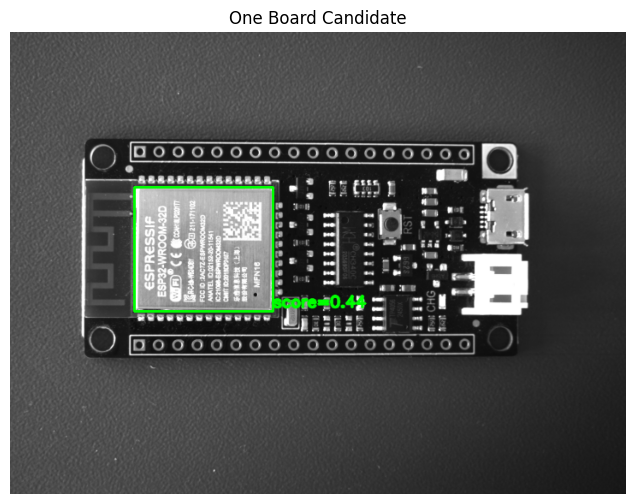

In [403]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 14
# Draw one candidate dictionary
# ------------------------------------------------------------

candidate_vis = frame_resized_bgr.copy()

cv2.drawContours(
    candidate_vis,
    [best_candidate["box"]],
    0,
    (0, 255, 0),
    2
)

x, y = best_candidate["box"][0]
label = f"score={best_candidate['geometry_score']:.2f}"

cv2.putText(
    candidate_vis,
    label,
    (int(x), int(y) - 5),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 255, 0),
    2,
    cv2.LINE_AA
)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(candidate_vis, cv2.COLOR_BGR2RGB))
plt.title("One Board Candidate")
plt.axis("off")
plt.show()

In [404]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 15
# Full function after understanding each part
# ------------------------------------------------------------

def find_board_candidates(binary_image, source_name, image_shape):
    """
    Find possible PCB board candidates from a binary or edge image.
    """
    contours, _ = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []
    expected_aspect = 900 / 460

    for contour in contours:
        contour_area = cv2.contourArea(contour)

        if contour_area < 100:
            continue

        rect = cv2.minAreaRect(contour)
        info = analyze_rotated_rect(rect, image_shape)

        if info is None:
            continue

        area_ratio = info["area_ratio"]
        aspect_ratio = info["aspect_ratio"]

        min_area_ratio = 0.005
        max_area_ratio = 0.95

        min_aspect_ratio = 0.8
        max_aspect_ratio = 5.0

        if not (min_area_ratio <= area_ratio <= max_area_ratio):
            continue

        if not (min_aspect_ratio <= aspect_ratio <= max_aspect_ratio):
            continue

        aspect_error = abs(aspect_ratio - expected_aspect)
        aspect_score = max(0.0, 1.0 - aspect_error / expected_aspect)

        area_score = min(area_ratio / 0.25, 1.0)

        geometry_score = 0.6 * aspect_score + 0.4 * area_score

        candidate = {
            "source": source_name,
            "contour": contour,
            "rect": rect,
            "box": rect_to_box(rect),
            "info": info,
            "geometry_score": geometry_score,
        }

        candidates.append(candidate)

    candidates = sorted(
        candidates,
        key=lambda c: c["geometry_score"],
        reverse=True
    )

    return candidates

In [405]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 16
# Run candidate detection
# ------------------------------------------------------------

canny_candidates = find_board_candidates(
    canny_edges,
    source_name="canny",
    image_shape=frame_resized_bgr.shape
)

morph_candidates = find_board_candidates(
    morph_cleaned,
    source_name="morphology",
    image_shape=frame_resized_bgr.shape
)

all_candidates = canny_candidates + morph_candidates

all_candidates = sorted(
    all_candidates,
    key=lambda c: c["geometry_score"],
    reverse=True
)

print("Board Candidate Detection")
print("-------------------------")
print(f"Canny candidates      : {len(canny_candidates)}")
print(f"Morphology candidates : {len(morph_candidates)}")
print(f"Total candidates      : {len(all_candidates)}")

print("\nTop candidates:")
for i, candidate in enumerate(all_candidates[:10]):
    info = candidate["info"]
    print(
        f"{i+1}. source={candidate['source']}, "
        f"score={candidate['geometry_score']:.3f}, "
        f"area_ratio={info['area_ratio']:.3f}, "
        f"aspect_ratio={info['aspect_ratio']:.2f}, "
        f"angle={info['angle']:.1f}"
    )

Board Candidate Detection
-------------------------
Canny candidates      : 2
Morphology candidates : 3
Total candidates      : 5

Top candidates:
1. source=canny, score=0.439, area_ratio=0.060, aspect_ratio=1.12, angle=-90.0
2. source=morphology, score=0.425, area_ratio=0.065, aspect_ratio=1.04, angle=-90.0
3. source=morphology, score=0.376, area_ratio=0.010, aspect_ratio=1.18, angle=-90.0
4. source=canny, score=0.370, area_ratio=0.010, aspect_ratio=1.16, angle=-90.0
5. source=morphology, score=0.350, area_ratio=0.014, aspect_ratio=1.07, angle=-90.0


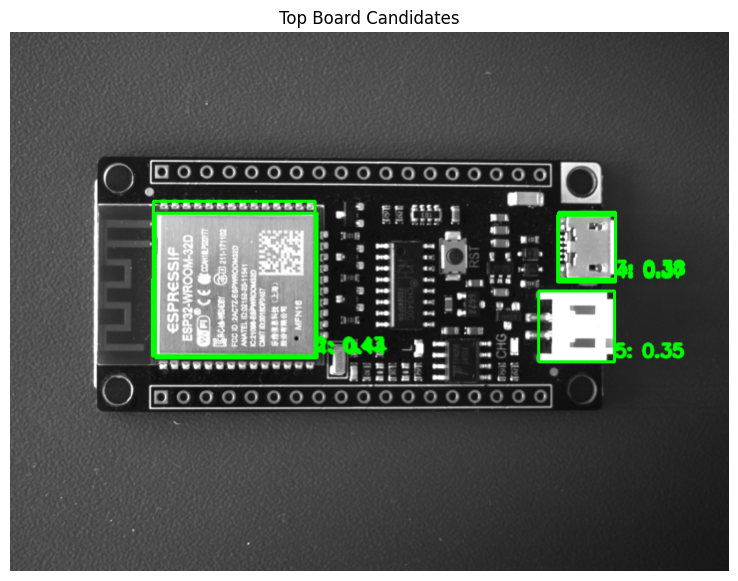

In [406]:
# ------------------------------------------------------------
# Board Candidate Detection - Cell 17
# Draw top candidates
# ------------------------------------------------------------

def draw_candidates(image_bgr, candidates, max_candidates=5):
    """
    Draw candidate rotated rectangles on a copy of the image.
    """
    output = image_bgr.copy()

    for idx, candidate in enumerate(candidates[:max_candidates]):
        box = candidate["box"]
        score = candidate["geometry_score"]

        cv2.drawContours(output, [box], 0, (0, 255, 0), 2)

        x, y = box[0]
        label = f"{idx+1}: {score:.2f}"

        cv2.putText(
            output,
            label,
            (int(x), int(y) - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    return output

all_vis_bgr = draw_candidates(
    frame_resized_bgr,
    all_candidates,
    max_candidates=5
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(all_vis_bgr, cv2.COLOR_BGR2RGB))
plt.title("Top Board Candidates")
plt.axis("off")
plt.show()

In [407]:
# ------------------------------------------------------------
# Board Candidate Detection - Use only Canny for board candidates
# ------------------------------------------------------------

canny_candidates = find_board_candidates(
    canny_edges,
    source_name="canny",
    image_shape=frame_resized_bgr.shape
)

# Temporarily disable morphology candidates
morph_candidates = []

all_candidates = canny_candidates

all_candidates = sorted(
    all_candidates,
    key=lambda c: c["geometry_score"],
    reverse=True
)

print("Board Candidate Detection")
print("-------------------------")
print(f"Canny candidates      : {len(canny_candidates)}")
print(f"Morphology candidates : {len(morph_candidates)}")
print(f"Total candidates      : {len(all_candidates)}")

print("\nTop candidates:")
for i, candidate in enumerate(all_candidates[:10]):
    info = candidate["info"]
    print(
        f"{i+1}. source={candidate['source']}, "
        f"score={candidate['geometry_score']:.3f}, "
        f"area_ratio={info['area_ratio']:.3f}, "
        f"aspect_ratio={info['aspect_ratio']:.2f}, "
        f"angle={info['angle']:.1f}"
    )

Board Candidate Detection
-------------------------
Canny candidates      : 2
Morphology candidates : 0
Total candidates      : 2

Top candidates:
1. source=canny, score=0.439, area_ratio=0.060, aspect_ratio=1.12, angle=-90.0
2. source=canny, score=0.370, area_ratio=0.010, aspect_ratio=1.16, angle=-90.0


In [408]:
# ------------------------------------------------------------
# Debug: Check if real board-like candidates exist
# ------------------------------------------------------------

board_like_candidates = []

for candidate in all_candidates:
    info = candidate["info"]

    area_ratio = info["area_ratio"]
    aspect_ratio = info["aspect_ratio"]

    if 0.08 <= area_ratio <= 0.40 and 1.5 <= aspect_ratio <= 2.8:
        board_like_candidates.append(candidate)

print("Board-like candidate check")
print("--------------------------")
print(f"Total candidates      : {len(all_candidates)}")
print(f"Board-like candidates : {len(board_like_candidates)}")

for i, candidate in enumerate(board_like_candidates[:10]):
    info = candidate["info"]
    print(
        f"{i+1}. source={candidate['source']}, "
        f"geometry={candidate['geometry_score']:.3f}, "
        f"area_ratio={info['area_ratio']:.3f}, "
        f"aspect_ratio={info['aspect_ratio']:.2f}, "
        f"angle={info['angle']:.1f}"
    )

Board-like candidate check
--------------------------
Total candidates      : 2
Board-like candidates : 0


# Step 4: Board Candidate Detection

In this step, we search for possible PCB board candidates.

The goal is not to make the final board decision yet.  
The goal is to generate rectangular regions that could be the PCB.

We use classical computer vision methods:

1. Use edge or binary images from preprocessing.
2. Find contours.
3. Approximate each contour with a rotated rectangle.
4. Filter candidates by:
   - area,
   - aspect ratio,
   - rectangular shape,
   - image size relation.

The PCB board is expected to be a relatively large rectangular object.  
Therefore, small contours and contours with unrealistic aspect ratios are rejected.

This step produces candidate boxes.  
The final decision will be done later in the Board Scoring step.

Board Candidate Detection
-------------------------
Canny candidates      : 2
Morphology candidates : 3
Total candidates      : 5

Top candidates:
1. source=canny, score=0.439, area_ratio=0.060, aspect_ratio=1.12, angle=-90.0
2. source=morphology, score=0.425, area_ratio=0.065, aspect_ratio=1.04, angle=-90.0
3. source=morphology, score=0.376, area_ratio=0.010, aspect_ratio=1.18, angle=-90.0
4. source=canny, score=0.370, area_ratio=0.010, aspect_ratio=1.16, angle=-90.0
5. source=morphology, score=0.350, area_ratio=0.014, aspect_ratio=1.07, angle=-90.0


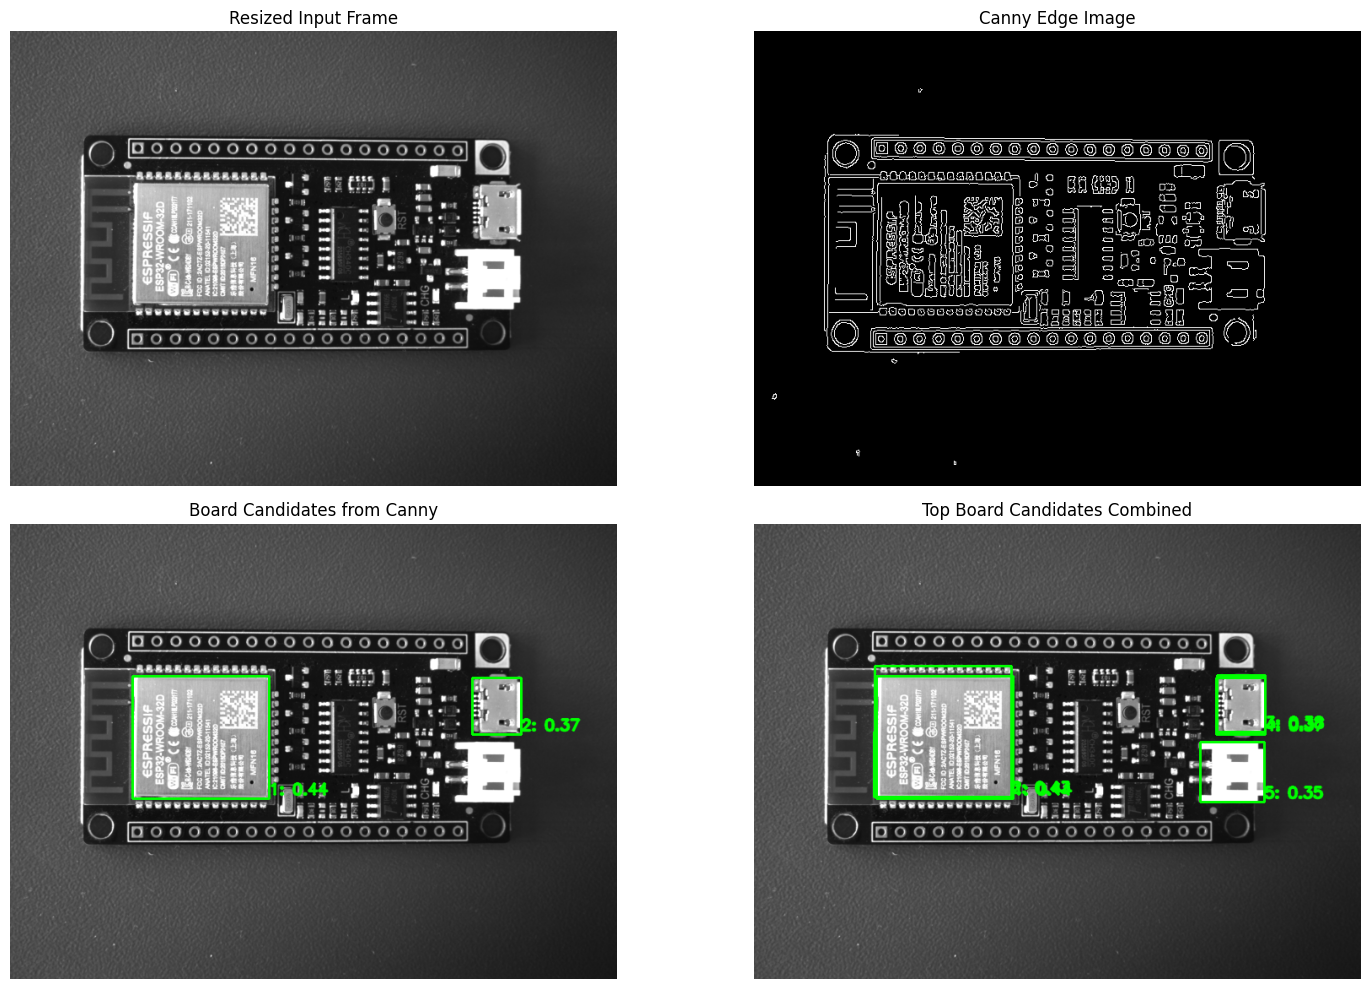

In [409]:
# ------------------------------------------------------------
# Step 4: Board Candidate Detection
# ------------------------------------------------------------
# In this cell, we generate possible board candidates.
#
# We use contours from:
# 1. Canny edge image
# 2. Morphology-cleaned threshold image
#
# Each contour is converted into a rotated rectangle using cv2.minAreaRect.
# Then we filter the rectangles by area and aspect ratio.
#
# This step does not yet decide the final board.
# It only creates possible candidates.
# ------------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper function: convert OpenCV rotated rectangle to box points
# ------------------------------------------------------------
def rect_to_box(rect):
    """
    Convert a cv2.minAreaRect result into integer corner points.

    Parameters
    ----------
    rect:
        Rotated rectangle returned by cv2.minAreaRect.

    Returns
    -------
    box:
        Four corner points of the rotated rectangle.
    """
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    return box


# ------------------------------------------------------------
# Helper function: compute geometry information
# ------------------------------------------------------------
def analyze_rotated_rect(rect, image_shape):
    """
    Analyze a rotated rectangle and compute geometric properties.

    This function calculates:
    - width
    - height
    - area
    - area ratio relative to the image
    - aspect ratio

    The aspect ratio is always >= 1.
    """
    image_height, image_width = image_shape[:2]
    image_area = image_width * image_height

    (center_x, center_y), (rect_width, rect_height), angle = rect

    if rect_width <= 0 or rect_height <= 0:
        return None

    rect_area = rect_width * rect_height
    area_ratio = rect_area / image_area

    long_side = max(rect_width, rect_height)
    short_side = min(rect_width, rect_height)

    if short_side <= 0:
        return None

    aspect_ratio = long_side / short_side

    return {
        "center": (center_x, center_y),
        "width": rect_width,
        "height": rect_height,
        "area": rect_area,
        "area_ratio": area_ratio,
        "aspect_ratio": aspect_ratio,
        "angle": angle,
    }


# ------------------------------------------------------------
# Helper function: extract candidates from one binary image
# ------------------------------------------------------------
def find_board_candidates(binary_image, source_name, image_shape):
    """
    Find possible PCB board candidates from a binary image.

    Parameters
    ----------
    binary_image:
        Edge image or threshold/morphology image.
    source_name:
        Name of the preprocessing source, for example 'canny' or 'morphology'.
    image_shape:
        Shape of the original resized frame.

    Returns
    -------
    candidates:
        List of candidate dictionaries.
    """
    contours, _ = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []

    # Expected aspect ratio of the canonical board
    # Project canonical board size: 900 x 460
    expected_aspect = 900 / 460

    for contour in contours:
        contour_area = cv2.contourArea(contour)

        # Very small contours are not useful for board detection
        if contour_area < 200:
            continue

        rect = cv2.minAreaRect(contour)
        info = analyze_rotated_rect(rect, image_shape)

        if info is None:
            continue

        area_ratio = info["area_ratio"]
        aspect_ratio = info["aspect_ratio"]

        # --------------------------------------------------------
        # Candidate filtering
        # --------------------------------------------------------
        # The board should be a relatively large object in the image.
        # These values are starting parameters and can be tuned.
        min_area_ratio = 0.009
        max_area_ratio = 0.95

        # The FireBeetle board is roughly rectangular.
        # The canonical ratio is about 1.96.
        # We allow a wider range because perspective can distort the shape.
        min_aspect_ratio = 0.8
        max_aspect_ratio = 5.0

        if not (min_area_ratio <= area_ratio <= max_area_ratio):
            continue

        if not (min_aspect_ratio <= aspect_ratio <= max_aspect_ratio):
            continue

        # Simple geometry score:
        # The closer the candidate aspect ratio is to the expected aspect ratio,
        # the better the score.
        aspect_error = abs(aspect_ratio - expected_aspect)
        aspect_score = max(0.0, 1.0 - aspect_error / expected_aspect)

        # Area score prefers larger candidates, but not too large.
        area_score = min(area_ratio / 0.25, 1.0)

        geometry_score = 0.6 * aspect_score + 0.4 * area_score

        candidate = {
            "source": source_name,
            "contour": contour,
            "rect": rect,
            "box": rect_to_box(rect),
            "info": info,
            "geometry_score": geometry_score,
        }

        candidates.append(candidate)

    # Sort candidates by geometry score
    candidates = sorted(
        candidates,
        key=lambda c: c["geometry_score"],
        reverse=True
    )

    return candidates


# ------------------------------------------------------------
# Find candidates from Canny and morphology images
# ------------------------------------------------------------
canny_candidates = find_board_candidates(
    canny_edges,
    source_name="canny",
    image_shape=frame_resized_bgr.shape
)

morph_candidates = find_board_candidates(
    morph_cleaned,
    source_name="morphology",
    image_shape=frame_resized_bgr.shape
)

# Combine all candidates
all_candidates = canny_candidates + morph_candidates

# Sort all candidates by geometry score
all_candidates = sorted(
    all_candidates,
    key=lambda c: c["geometry_score"],
    reverse=True
)

print("Board Candidate Detection")
print("-------------------------")
print(f"Canny candidates      : {len(canny_candidates)}")
print(f"Morphology candidates : {len(morph_candidates)}")
print(f"Total candidates      : {len(all_candidates)}")

# Print the best candidates
print("\nTop candidates:")
for i, candidate in enumerate(all_candidates[:5]):
    info = candidate["info"]
    print(
        f"{i+1}. source={candidate['source']}, "
        f"score={candidate['geometry_score']:.3f}, "
        f"area_ratio={info['area_ratio']:.3f}, "
        f"aspect_ratio={info['aspect_ratio']:.2f}, "
        f"angle={info['angle']:.1f}"
    )


# ------------------------------------------------------------
# Visualization helper
# ------------------------------------------------------------
def draw_candidates(image_bgr, candidates, max_candidates=5):
    """
    Draw candidate rotated rectangles on a copy of the image.
    """
    output = image_bgr.copy()

    for idx, candidate in enumerate(candidates[:max_candidates]):
        box = candidate["box"]
        score = candidate["geometry_score"]

        # Draw rotated rectangle
        cv2.drawContours(output, [box], 0, (0, 255, 0), 2)

        # Draw candidate number and score
        x, y = box[0]
        label = f"{idx+1}: {score:.2f}"
        cv2.putText(
            output,
            label,
            (int(x), int(y) - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    return output


# Draw candidates separately
canny_vis_bgr = draw_candidates(
    frame_resized_bgr,
    canny_candidates,
    max_candidates=5
)

morph_vis_bgr = draw_candidates(
    frame_resized_bgr,
    morph_candidates,
    max_candidates=5
)

all_vis_bgr = draw_candidates(
    frame_resized_bgr,
    all_candidates,
    max_candidates=5
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Resized Input Frame")
axes[0, 0].axis("off")

axes[0, 1].imshow(canny_edges, cmap="gray")
axes[0, 1].set_title("Canny Edge Image")
axes[0, 1].axis("off")

axes[1, 0].imshow(cv2.cvtColor(canny_vis_bgr, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Board Candidates from Canny")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(all_vis_bgr, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Top Board Candidates Combined")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Step 5: Board Scoring

In this step, we score all board candidates and select the best one.

Board Candidate Detection only produces possible rectangular regions.  
However, not every large rectangle is the PCB.  
A table edge, a shadow, a dark box, or another rectangular object can also create a candidate.

Therefore, we need a scoring step.

In this simplified notebook version, we use four scoring criteria:

1. Geometry score  
   Checks whether the candidate has a plausible board aspect ratio and size.

2. Edge density score  
   Checks whether the candidate contains enough internal edge structure.

3. Dark region score  
   Checks whether the candidate contains a reasonable amount of dark PCB-like area.

4. Fill score  
   Checks whether the contour fills its rotated rectangle well.

The final board score is a weighted combination of these scores.

The best candidate is the candidate with the highest final board score.

In [410]:
print("Candidate check")
print("---------------")
print(f"canny_candidates      : {len(canny_candidates) if 'canny_candidates' in globals() else 'not defined'}")
print(f"morph_candidates      : {len(morph_candidates) if 'morph_candidates' in globals() else 'not defined'}")
print(f"all_candidates        : {len(all_candidates) if 'all_candidates' in globals() else 'not defined'}")

Candidate check
---------------
canny_candidates      : 2
morph_candidates      : 3
all_candidates        : 5


Board Scoring
-------------
Number of scored canidates: 5


,rank,source,final_score,geometry,edge,dark,fill,edge_density,dark_ratio,fill_ratio,area_ratio,aspect_ratio,angle
0,1,canny,0.481786,0.439287,1.0,0.0,1.0,0.176948,0.049752,0.983482,0.060417,1.117241,-90.0
1,2,morphology,0.477521,0.425069,1.0,0.0,1.0,0.171528,0.062025,0.913049,0.065401,1.044872,-90.0
2,3,morphology,0.462855,0.376184,1.0,0.0,1.0,0.169371,0.069473,0.933229,0.009823,1.175439,-90.0
3,4,morphology,0.455141,0.350469,1.0,0.0,1.0,0.087302,0.095058,0.862305,0.013879,1.070423,-90.0
4,5,canny,0.361073,0.370245,1.0,0.0,0.0,0.169741,0.083250,0.052239,0.009995,1.155172,-90.0


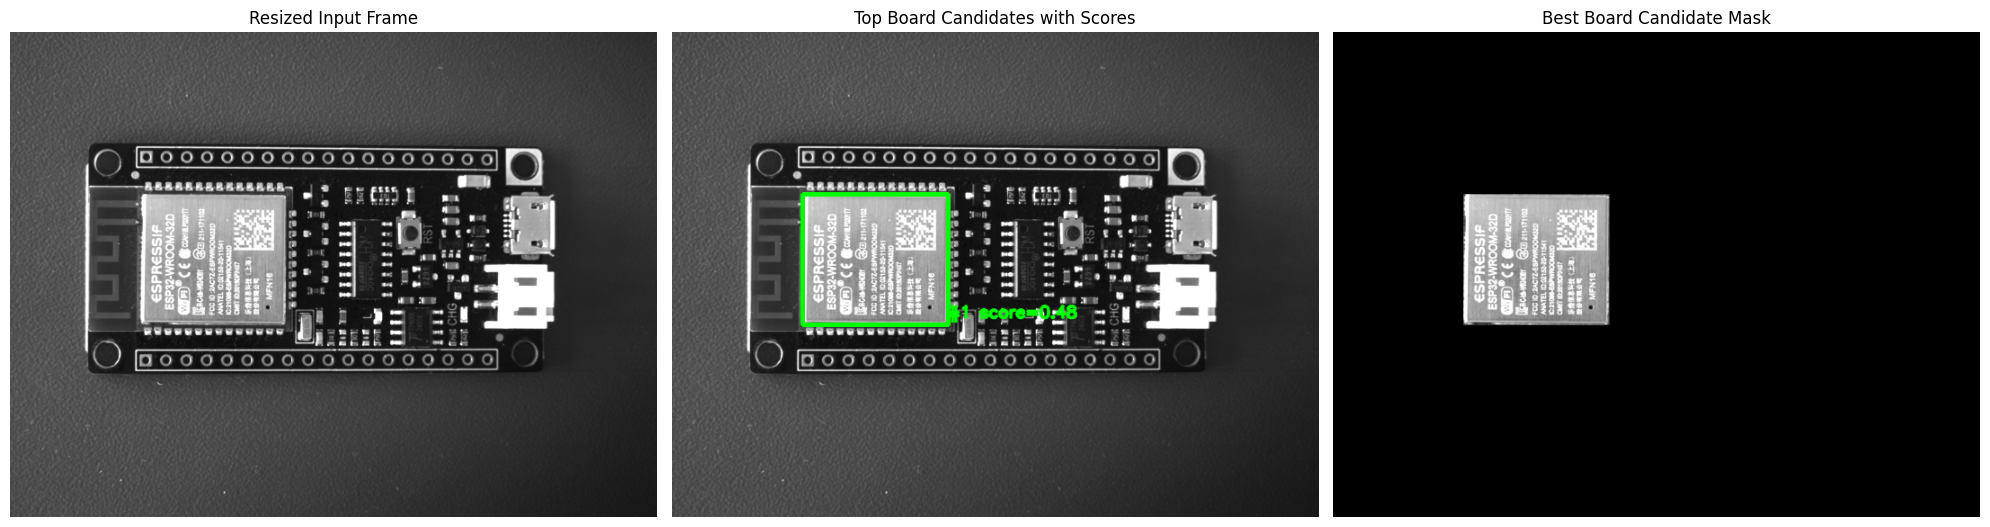

In [411]:
# ------------------------------------------------------------
# Step 5: Board Scoring
# ------------------------------------------------------------
# Goal:
# Select the most plausible PCB board candidate from all_candidates.
#
# Input:
# - all_candidates: list of candidate dictionaries from Board Candidate Detection
# - gray_blur: grayscale/blurred image
# - canny_edges: edge image
# - frame_resized_bgr: original resized color image
#
# Output:
# - scored_candidates: candidates with additional score information
# - best_board_candidate: candidate with the highest final score
# ------------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Helper 1: Clamp score values to range [0, 1]
# ------------------------------------------------------------
def clamp01(value):
    """
    Limit a value to the range [0, 1].

    Example:
    -0.3 becomes 0.0
     0.5 stays 0.5
     1.7 becomes 1.0
    """
    return max(0.0, min(1.0, float(value)))

# ------------------------------------------------------------
# Helper 2: Create a binary mask from a candidate box
# ------------------------------------------------------------
def create_candidate_mask(image_shape, box):
    """
    Create a binary mask for one rotated rectangle candidate.

    The mask has:
    - value 255 inside the candidate
    - value 0 outside the candidate

    This allows us to analyze only the candidate region.
    """
    mask = np.zeros(image_shape[:2], dtype=np.uint8)

    cv2.fillPoly(
        mask,
        [box.astype(np.int32)],
        255
    )

    return mask

# ------------------------------------------------------------
# Helper 3: Edge density score
# ------------------------------------------------------------
def compute_edge_density_score(edge_image, candidate_mask):
    """
    Compute how many edge pixels are inside the candidate.

    A real PCB should contain many internal edge structures:
    pins, connectors, module borders, holes, text, components.

    Formula:
    edge_density = edge_pixels_inside_candidate / candidate_area
    """
    candidate_area = np.count_nonzero(candidate_mask)

    if candidate_area == 0:
        return 0.0, 0.0
    
    edges_inside = cv2.bitwise_and(edge_image,edge_image, mask = candidate_mask)

    edge_pixels = np.count_nonzero(edges_inside)
    edge_density = edge_pixels / candidate_area

    # Tunable parameters
    min_density = 0.015
    good_density = 0.080

    score =  (edge_density - min_density) / (good_density - min_density)
    score = clamp01(score)

    return score, edge_density


# ------------------------------------------------------------
# Helper 4: Dark region score
# ------------------------------------------------------------
def compute_dark_region_score(gray_image, candidate_mask):
    """
    Compute how much of the candidate area is dark.

    The PCB board is usually darker than the background.
    Therefore, a plausible board candidate should contain
    a reasonable amount of dark pixels.
    """
    pixels = gray_image[candidate_mask > 0]

    if pixels.size == 0:
        return 0.0, 0.0

    dark_threshold = 100
    dark_ratio = np.mean(pixels < dark_threshold)

    # Tunable parameters
    min_dark_ratio = 0.10
    good_dark_ratio = 0.45

    score = (dark_ratio - min_dark_ratio) / (good_dark_ratio - min_dark_ratio)
    score = clamp01(score)

    return score, dark_ratio

# ------------------------------------------------------------
# Helper 5: Fill score
# ------------------------------------------------------------
def compute_fill_score(candidate):
    """
    Compute how well the contour fills its rotated rectangle.

    Formula:
    fill_ratio = contour_area / rectangle_area

    If fill_ratio is very low, the rectangle may be too loose
    or caused by a strange/noisy contour.
    """
    contour = candidate["contour"]
    rect_info = candidate["info"]

    contour_area = cv2.contourArea(contour)
    rect_area = rect_info["area"]

    if rect_area <= 0:
        return 0.0, 0.0

    fill_ratio = contour_area / rect_area

    # Tunable parameters
    min_fill = 0.25
    good_fill = 0.75

    score = (fill_ratio - min_fill) / (good_fill - min_fill)
    score = clamp01(score)

    return score, fill_ratio

def compute_board_size_score(area_ratio):
    min_board_area = 0.08
    good_board_area = 0.25

    score = (area_ratio - min_board_area) / (good_board_area - min_board_area)
    return clamp01(score)
# ------------------------------------------------------------
# Main function: Score one board candidate
# ------------------------------------------------------------
def score_board_candidate(candidate, gray_image, edge_image, image_shape):
    """
    Compute all scores for one candidate and return a scored candidate.

    The candidate already has:
    - contour
    - rect
    - box
    - info
    - geometry_score

    Here we add:
    - edge_score
    - dark_score
    - fill_score
    - final_score
    """

    box = candidate["box"]

    # create mask for this candidate
    mask = create_candidate_mask(image_shape=image_shape, box= box)

    # Existing geometry score from previous step
    geometry_score = candidate["geometry_score"]

    # New Scores
    edge_score, edge_density = compute_edge_density_score(edge_image=edge_image,candidate_mask=mask)

    dark_score, dark_ratio = compute_dark_region_score(gray_image=gray_image, candidate_mask=mask)

    fill_score, fill_ratio = compute_fill_score(candidate)

    size_score = compute_board_size_score(candidate["info"]["area_ratio"])

    # Weighted final score
    final_score = (
        0.30*geometry_score +
        0.25*size_score +
        0.25*edge_score +
        0.10*dark_score +
        0.10*fill_score

     )
    # Copy original candidate and add new information
    scored_candidate = candidate.copy()

    scored_candidate["mask"] = mask

    scored_candidate["scores"] = {
        "geometry_score": geometry_score,
        "edge_score": edge_score,
        "dark_score": dark_score,
        "fill_score": fill_score,
        "final_score": final_score,
        "edge_density": edge_density,
        "dark_ratio": dark_ratio,
        "fill_ratio": fill_ratio,
    }

    return scored_candidate


# ------------------------------------------------------------
# Score all candidates
# ------------------------------------------------------------

scored_candidates = []

for candidate in all_candidates:
    scored  = score_board_candidate(
        candidate=candidate,
        gray_image=gray_blur,
        edge_image=canny_edges,
        image_shape=frame_resized_bgr.shape
    )

    scored_candidates.append(scored)


# ------------------------------------------------------------
# Sort candidates by final score
# ------------------------------------------------------------
scored_candidates = sorted(
    scored_candidates,
    key=lambda c: c["scores"]["final_score"],
    reverse=True
)

best_board_candidate = scored_candidates[0] if len(scored_candidates) > 0 else None 
# ------------------------------------------------------------
# Print results as table
# ------------------------------------------------------------

rows = []

for i, candidate in enumerate(scored_candidates[:10]):
    scores = candidate["scores"]
    info = candidate["info"]

    rows.append({
        "rank": i + 1,
        "source": candidate["source"],
        "final_score": scores["final_score"],
        "geometry": scores["geometry_score"],
        "edge": scores["edge_score"],
        "dark": scores["dark_score"],
        "fill": scores["fill_score"],
        "edge_density": scores["edge_density"],
        "dark_ratio": scores["dark_ratio"],
        "fill_ratio": scores["fill_ratio"],
        "area_ratio": info["area_ratio"],
        "aspect_ratio": info["aspect_ratio"],
        "angle": info["angle"],
    })

score_df = pd.DataFrame(rows)

print("Board Scoring")
print("-------------")
print(f"Number of scored canidates: { len(scored_candidates)}")

display(score_df)
# ------------------------------------------------------------
# Visualization helper
# ------------------------------------------------------------

def draw_scored_candidates(image_bgr, canididates, max_candidates = 5):
    """
    Draw top scored candidates on the image.
    The best candidate is drawn thicker.
    """
    output = image_bgr.copy()

    for idx, candidate in enumerate(canididates[:max_candidates]):
        box = candidate["box"]
        final_score = candidate["scores"]["final_score"]

        thickness = 4 if idx == 0 else 2

        cv2.drawContours(
            output,
            [box],
            0,
            (0, 255, 0),
            thickness
        )

        x,y = box[0]
        label = f"#{idx+1} score={final_score:.2f}"

        cv2.putText(
            output,
            label,
            (int(x), int(y) - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

        return output
    


# ------------------------------------------------------------
# Create visualizations
# ------------------------------------------------------------
scoring_vis_bgr = draw_scored_candidates(
    frame_resized_bgr,
    scored_candidates,
    max_candidates=5
)

if best_board_candidate is not None:
    best_mask = best_board_candidate["mask"]

    masked_board_bgr = cv2.bitwise_and(
        frame_resized_bgr,
        frame_resized_bgr,
        mask=best_mask
    )
else:
    best_mask = np.zeros(frame_resized_bgr.shape[:2], dtype=np.uint8)
    masked_board_bgr = frame_resized_bgr.copy()


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Resized Input Frame")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(scoring_vis_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Top Board Candidates with Scores")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(masked_board_bgr, cv2.COLOR_BGR2RGB))
axes[2].set_title("Best Board Candidate Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()



# Step 6: Perspective Warp / Homography

In this step, we transform the PCB board into a fixed canonical view.

The current automatic board candidate is not yet reliable enough because it selected only a part of the PCB.  
Therefore, for learning and debugging, we first select the four board corners manually.

The four source points are:

1. top-left corner
2. top-right corner
3. bottom-right corner
4. bottom-left corner

These four points are mapped to a fixed target rectangle with size:

- width: 900 px
- height: 460 px

This creates the canonical board view.

The homography removes perspective distortion and makes the component positions more stable for later ROI-based component detection.

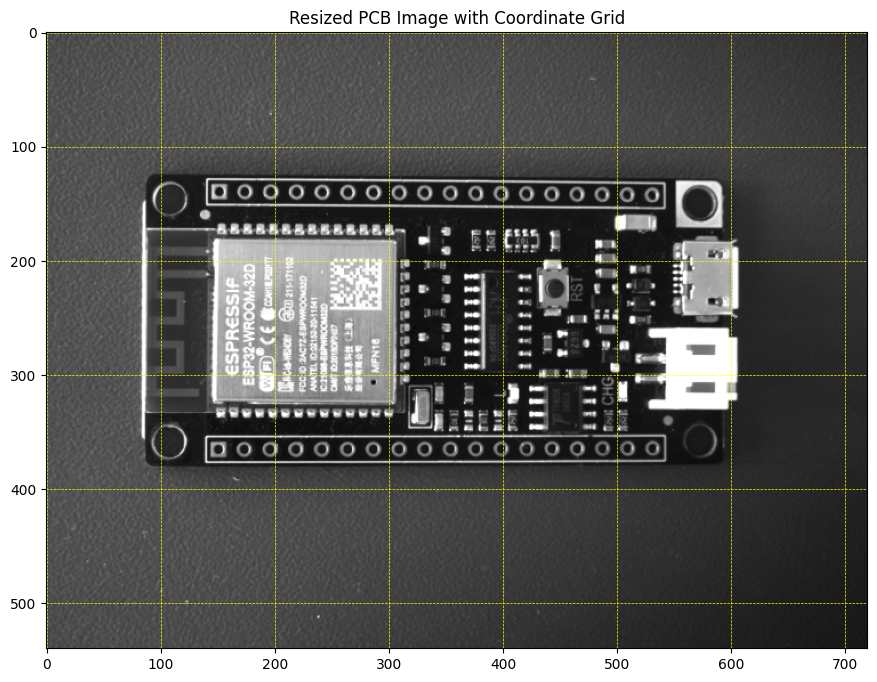

Image shape:
height = 540 px
width  = 720 px


In [412]:
# ------------------------------------------------------------
# Step 6A: Show resized image with coordinate grid
# ------------------------------------------------------------
# We use this image to manually estimate the four board corners.
# Coordinate system:
# x-axis goes from left to right
# y-axis goes from top to bottom
# ------------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

if "frame_resized_bgr" not in globals():
    raise NameError(
        "frame_resized_bgr is not defined. "
        "Please run Frame Source and Resize cells first."
    )

frame_resized_rgb = cv2.cvtColor(frame_resized_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(frame_resized_rgb)
plt.title("Resized PCB Image with Coordinate Grid")
plt.axis("on")
plt.grid(color="yellow", linestyle="--", linewidth=0.5)
plt.show()

print("Image shape:")
print(f"height = {frame_resized_bgr.shape[0]} px")
print(f"width  = {frame_resized_bgr.shape[1]} px")

In [413]:
# ------------------------------------------------------------
# Step 6B: Define manual PCB board corners
# ------------------------------------------------------------
# Order is very important:
# 1. top-left
# 2. top-right
# 3. bottom-right
# 4. bottom-left
#
# These coordinates are manually estimated from the resized image.
# ------------------------------------------------------------

src_points = np.array([
    [85, 125],    # 1: top-left board corner
    [615, 125],   # 2: top-right board corner
    [615, 380],   # 3: bottom-right board corner
    [85, 380]     # 4: bottom-left board corner
], dtype=np.float32)

print("Manual source points:")
for i, point in enumerate(src_points):
    print(f"{i+1}: x={point[0]:.1f}, y={point[1]:.1f}")

Manual source points:
1: x=85.0, y=125.0
2: x=615.0, y=125.0
3: x=615.0, y=380.0
4: x=85.0, y=380.0


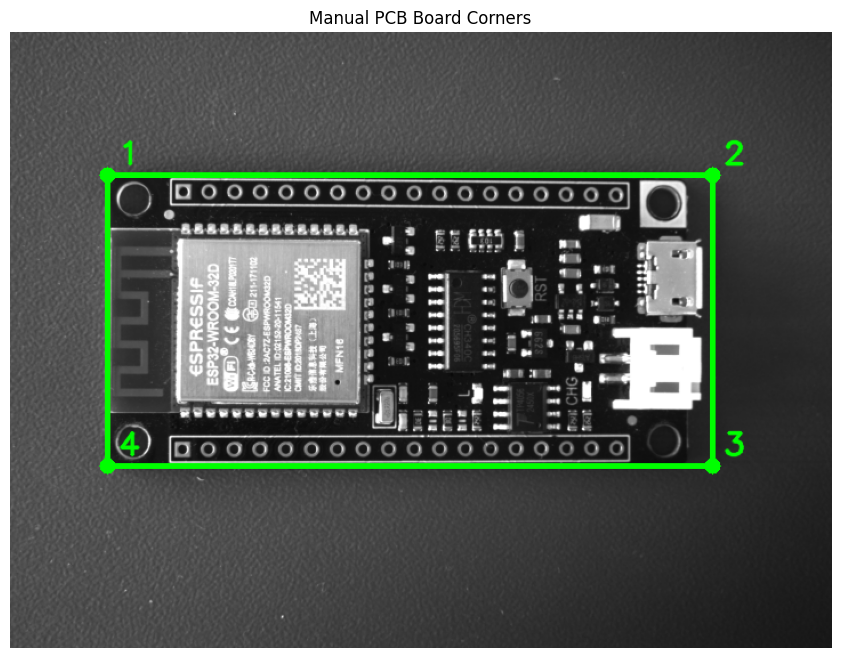

In [414]:
# ------------------------------------------------------------
# Step 6C: Visual check of manual board corners
# ------------------------------------------------------------
# This cell draws the selected corner points and connects them.
# The green polygon should cover the full outer PCB board.
# ------------------------------------------------------------

corner_vis_bgr = frame_resized_bgr.copy()

# Draw corner points and numbers
for idx, point in enumerate(src_points):
    x, y = int(point[0]), int(point[1])

    cv2.circle(
        corner_vis_bgr,
        (x, y),
        7,
        (0, 255, 0),
        -1
    )

    cv2.putText(
        corner_vis_bgr,
        str(idx + 1),
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )

# Draw polygon
cv2.polylines(
    corner_vis_bgr,
    [src_points.astype(np.int32)],
    isClosed=True,
    color=(0, 255, 0),
    thickness=3
)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(corner_vis_bgr, cv2.COLOR_BGR2RGB))
plt.title("Manual PCB Board Corners")
plt.axis("off")
plt.show()

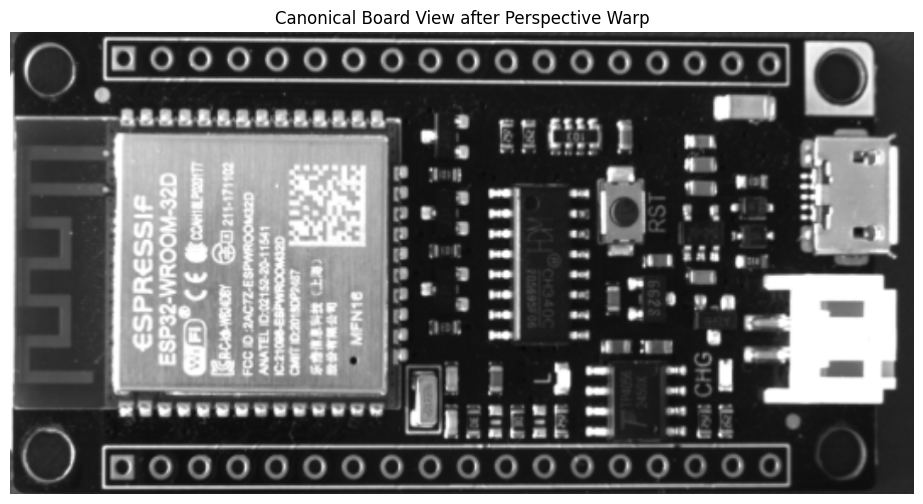

In [415]:
# ------------------------------------------------------------
# Step 6D: Perspective Warp / Homography
# ------------------------------------------------------------

CANONICAL_WIDTH = 900
CANONICAL_HEIGHT = 460

dst_points = np.array([
    [0, 0],                                      # top-left
    [CANONICAL_WIDTH - 1, 0],                    # top-right
    [CANONICAL_WIDTH - 1, CANONICAL_HEIGHT - 1], # bottom-right
    [0, CANONICAL_HEIGHT - 1]                    # bottom-left
], dtype=np.float32)

# Homography: source image points -> canonical target points
H = cv2.getPerspectiveTransform(src_points, dst_points)

board_warp_bgr = cv2.warpPerspective(
    frame_resized_bgr,
    H,
    (CANONICAL_WIDTH, CANONICAL_HEIGHT)
)

board_warp_rgb = cv2.cvtColor(board_warp_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(board_warp_rgb)
plt.title("Canonical Board View after Perspective Warp")
plt.axis("off")
plt.show()

In [416]:
import cv2
from pathlib import Path

output_dir = Path("outputs/manual_warp")
output_dir.mkdir(parents=True, exist_ok=True)

cv2.imwrite(str(output_dir / "manual_board_warp.png"), board_warp_bgr)

print("Saved:", output_dir / "manual_board_warp.png")

Saved: outputs/manual_warp/manual_board_warp.png


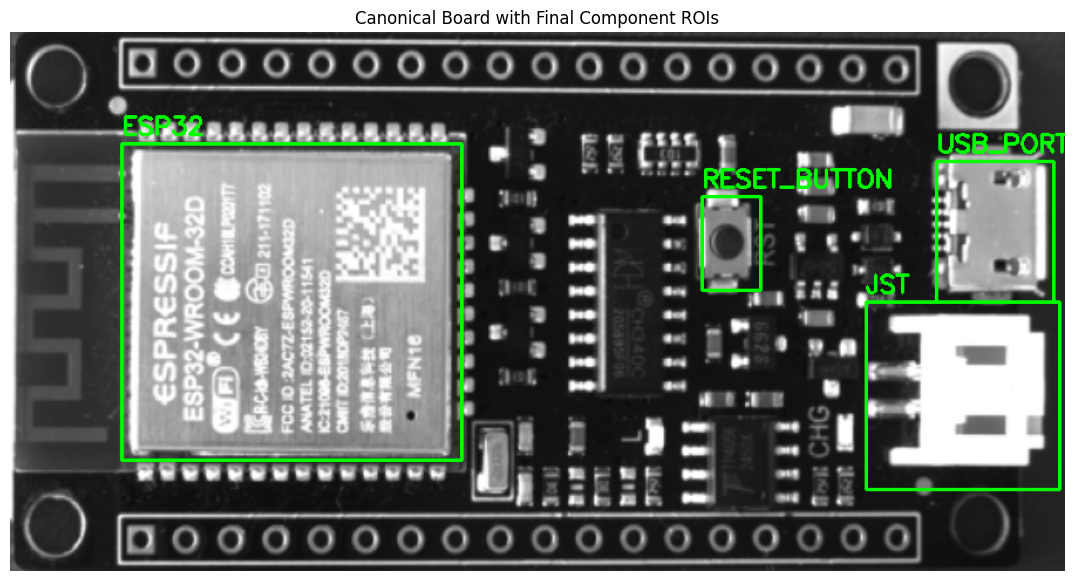

In [417]:
import matplotlib.pyplot as plt
import cv2

ROIS = {
    "ESP32": (95, 95, 385, 365),
    "RESET_BUTTON": (590, 140, 640, 220),
    "USB_PORT": (790, 110, 890, 230),
    "JST": (730, 230, 895, 390),
}

vis = board_warp_bgr.copy()

for name, (x1, y1, x2, y2) in ROIS.items():
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        name,
        (x1, max(y1 - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))
plt.imshow(vis_rgb)
plt.title("Canonical Board with Final Component ROIs")
plt.axis("off")
plt.show()

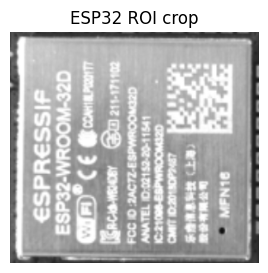

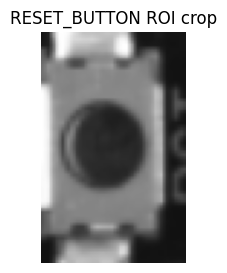

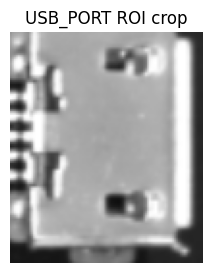

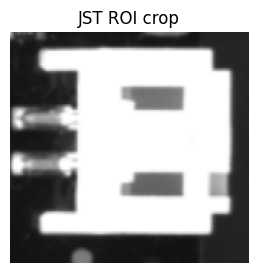

In [418]:
for name, (x1, y1, x2, y2) in ROIS.items():
    crop = board_warp_bgr[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 3))
    plt.imshow(crop_rgb)
    plt.title(f"{name} ROI crop")
    plt.axis("off")
    plt.show()

In [419]:
from pathlib import Path
import cv2

template_dir = Path("assets/templates/manual_components")
template_dir.mkdir(parents=True, exist_ok=True)

for name, (x1, y1, x2, y2) in ROIS.items():
    crop = board_warp_bgr[y1:y2, x1:x2]
    out_path = template_dir / f"{name.lower()}_template.png"
    cv2.imwrite(str(out_path), crop)
    print("Saved:", out_path)

Saved: assets/templates/manual_components/esp32_template.png
Saved: assets/templates/manual_components/reset_button_template.png
Saved: assets/templates/manual_components/usb_port_template.png
Saved: assets/templates/manual_components/jst_template.png


In [420]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

BASE_DIR = Path("/home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/outputs_pipeline_test")

board_path = BASE_DIR / "manual_warp" / "manual_board_warp.png"

template_paths = {
    "ESP32": BASE_DIR / "manual_components" / "esp32_template.png",
    "JST": BASE_DIR / "manual_components" / "jst_template.png",
    "RESET_BUTTON": BASE_DIR / "manual_components" / "reset_button_template.png",
    "USB_PORT": BASE_DIR / "manual_components" / "usb_port_template.png",
}

board_bgr = cv2.imread(str(board_path))

if board_bgr is None:
    raise FileNotFoundError(f"Board image not found: {board_path}")

board_gray = cv2.cvtColor(board_bgr, cv2.COLOR_BGR2GRAY)

print("Board loaded:", board_bgr.shape)

for name, path in template_paths.items():
    img = cv2.imread(str(path))
    if img is None:
        print(f"{name}: NOT FOUND -> {path}")
    else:
        print(f"{name}: loaded -> {img.shape}")

Board loaded: (460, 900, 3)
ESP32: loaded -> (270, 290, 3)
JST: loaded -> (115, 165, 3)
RESET_BUTTON: loaded -> (85, 70, 3)
USB_PORT: loaded -> (140, 135, 3)


In [421]:
from pathlib import Path
import cv2

BASE_DIR = Path("/home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/outputs_pipeline_test")

board_path = BASE_DIR / "manual_warp" / "manual_board_warp.png"
template_dir = BASE_DIR / "manual_components"
template_dir.mkdir(parents=True, exist_ok=True)

board_bgr = cv2.imread(str(board_path))

if board_bgr is None:
    raise FileNotFoundError(f"Board image not found: {board_path}")

ROIS = {
    "ESP32": (95, 95, 385, 365),
    "RESET_BUTTON": (610, 165, 680, 250),
    "USB_PORT": (760, 115, 895, 255),
    "JST": (730, 275, 895, 390),
}

for name, (x1, y1, x2, y2) in ROIS.items():
    crop = board_bgr[y1:y2, x1:x2]

    out_path = template_dir / f"{name.lower()}_template.png"
    cv2.imwrite(str(out_path), crop)

    print(f"{name}: saved {out_path}, shape={crop.shape}")

ESP32: saved /home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/outputs_pipeline_test/manual_components/esp32_template.png, shape=(270, 290, 3)
RESET_BUTTON: saved /home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/outputs_pipeline_test/manual_components/reset_button_template.png, shape=(85, 70, 3)
USB_PORT: saved /home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/outputs_pipeline_test/manual_components/usb_port_template.png, shape=(140, 135, 3)
JST: saved /home/emrahtek/Schreibtisch/CodeLab/PCB_Bauteilerkennung/outputs_pipeline_test/manual_components/jst_template.png, shape=(115, 165, 3)


In [422]:
ROIS = {
    "ESP32": (95, 95, 385, 365),
    "RESET_BUTTON": (610, 165, 680, 250),
    "USB_PORT": (760, 115, 895, 255),
    "JST": (730, 275, 895, 390),
}

detections = {}

for name, template_path in template_paths.items():
    template_bgr = cv2.imread(str(template_path))

    if template_bgr is None:
        print(f"Template not found: {template_path}")
        continue

    template_gray = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2GRAY)

    x1, y1, x2, y2 = ROIS[name]
    roi_gray = board_gray[y1:y2, x1:x2]

    result = cv2.matchTemplate(
        roi_gray,
        template_gray,
        cv2.TM_CCOEFF_NORMED
    )

    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    h, w = template_gray.shape[:2]

    top_left = (x1 + max_loc[0], y1 + max_loc[1])
    bottom_right = (top_left[0] + w, top_left[1] + h)

    detections[name] = {
        "score": max_val,
        "top_left": top_left,
        "bottom_right": bottom_right,
    }

    print(f"{name}: score={max_val:.3f}, box={top_left} -> {bottom_right}")

ESP32: score=1.000, box=(95, 95) -> (385, 365)
JST: score=1.000, box=(730, 275) -> (895, 390)
RESET_BUTTON: score=1.000, box=(610, 165) -> (680, 250)
USB_PORT: score=1.000, box=(760, 115) -> (895, 255)


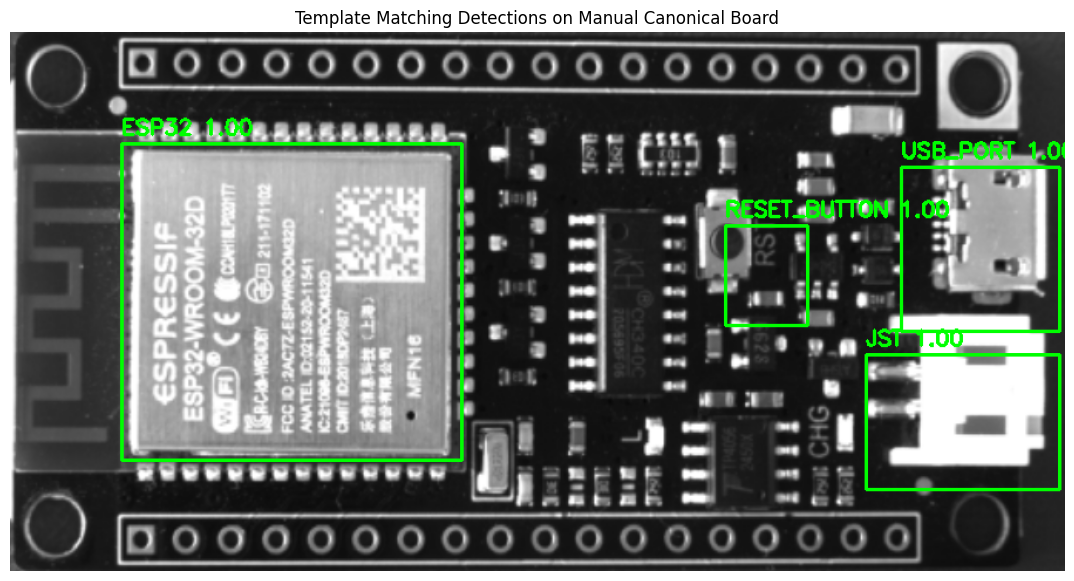

In [423]:
vis = board_bgr.copy()

for name, det in detections.items():
    score = det["score"]
    top_left = det["top_left"]
    bottom_right = det["bottom_right"]

    cv2.rectangle(vis, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(
        vis,
        f"{name} {score:.2f}",
        (top_left[0], max(top_left[1] - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))
plt.imshow(vis_rgb)
plt.title("Template Matching Detections on Manual Canonical Board")
plt.axis("off")
plt.show()